# Project Overview: Regression with a Crab Age Dataset
**Objective:** To predict discrete crab age based on physical and morphological features, focusing on mitigating severe multicollinearity through engineered density/volume proxies to minimize the Mean Absolute Error (MAE) metric.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s3e16')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s3e16


In [ ]:
#!pip install "numpy<2" "scikit-learn==1.3.2" --force-reinstall

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
import joblib
import pickle

In [3]:
print(np.__version__)

1.26.4


## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [4]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e16/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e16/test.csv')

In [5]:
train_df.head()

,id,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,0,I,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,9
1,1,I,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,8
2,2,M,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,9
3,3,F,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,11
4,4,I,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,8


In [6]:
test_df.head()

,id,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight
0,74051,I,1.0500,0.7625,0.2750,8.618248,3.657085,1.729319,2.721552
1,74052,I,1.1625,0.8875,0.2750,15.507176,7.030676,3.246018,3.968930
2,74053,F,1.2875,0.9875,0.3250,14.571643,5.556502,3.883882,4.819415
3,74054,F,1.5500,0.9875,0.3875,28.377849,13.380964,6.548735,7.030676
4,74055,I,1.1125,0.8500,0.2625,11.765042,5.528153,2.466407,3.331066


### 2.2. Checking Structural Metadata

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74051 entries, 0 to 74050
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              74051 non-null  int64  
 1   Sex             74051 non-null  object 
 2   Length          74051 non-null  float64
 3   Diameter        74051 non-null  float64
 4   Height          74051 non-null  float64
 5   Weight          74051 non-null  float64
 6   Shucked Weight  74051 non-null  float64
 7   Viscera Weight  74051 non-null  float64
 8   Shell Weight    74051 non-null  float64
 9   Age             74051 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 5.6+ MB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49368 entries, 0 to 49367
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              49368 non-null  int64  
 1   Sex             49368 non-null  object 
 2   Length          49368 non-null  float64
 3   Diameter        49368 non-null  float64
 4   Height          49368 non-null  float64
 5   Weight          49368 non-null  float64
 6   Shucked Weight  49368 non-null  float64
 7   Viscera Weight  49368 non-null  float64
 8   Shell Weight    49368 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 3.4+ MB


In [9]:
train_df.shape

(74051, 10)

In [10]:
test_df.shape

(49368, 9)

In [11]:
train_df.isnull().sum()

id                0
Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Age               0
dtype: int64

In [12]:
test_df.isnull().sum()

id                0
Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
dtype: int64

## 3. Exploratory Data Analysis

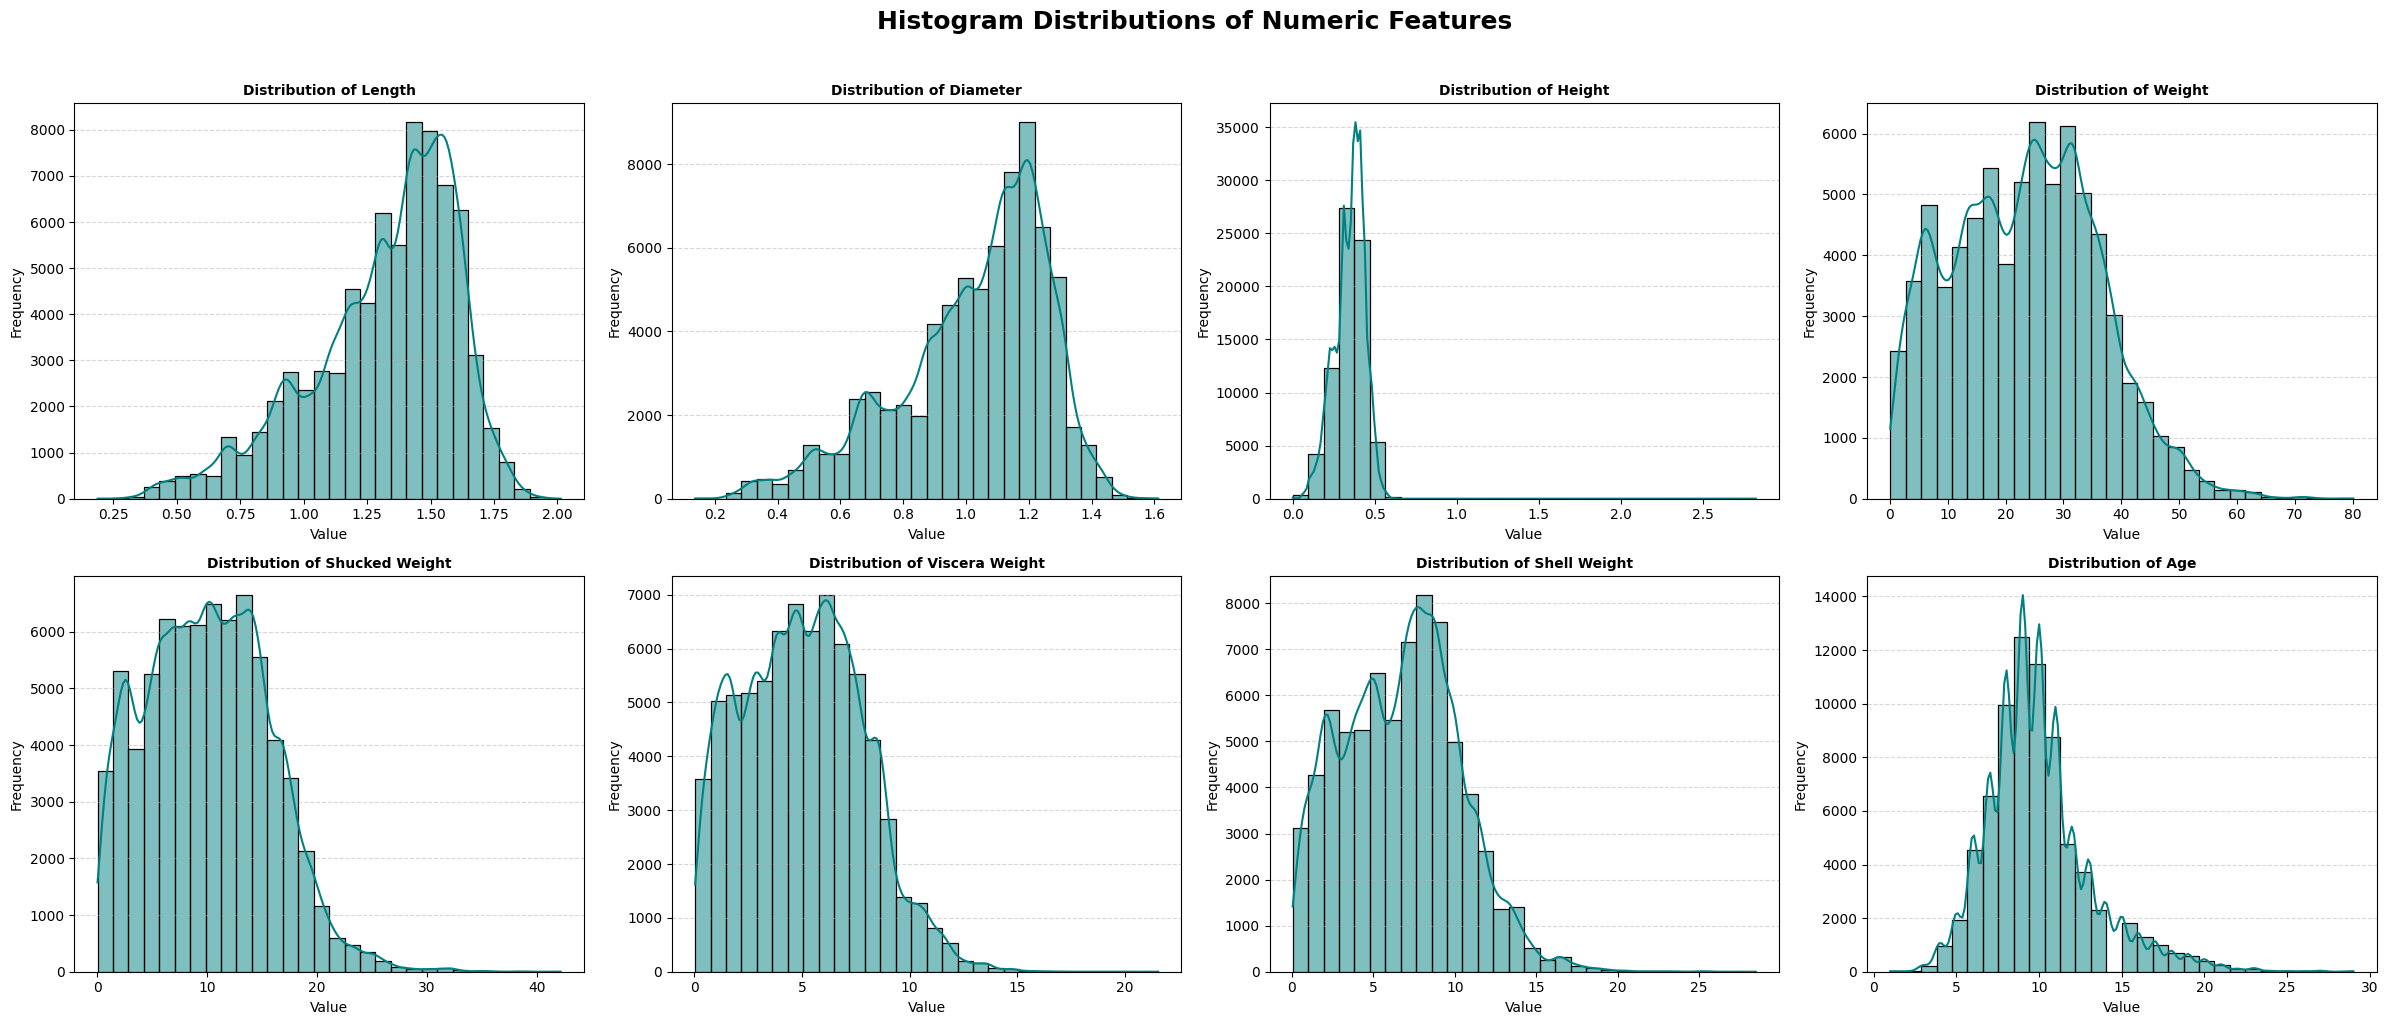

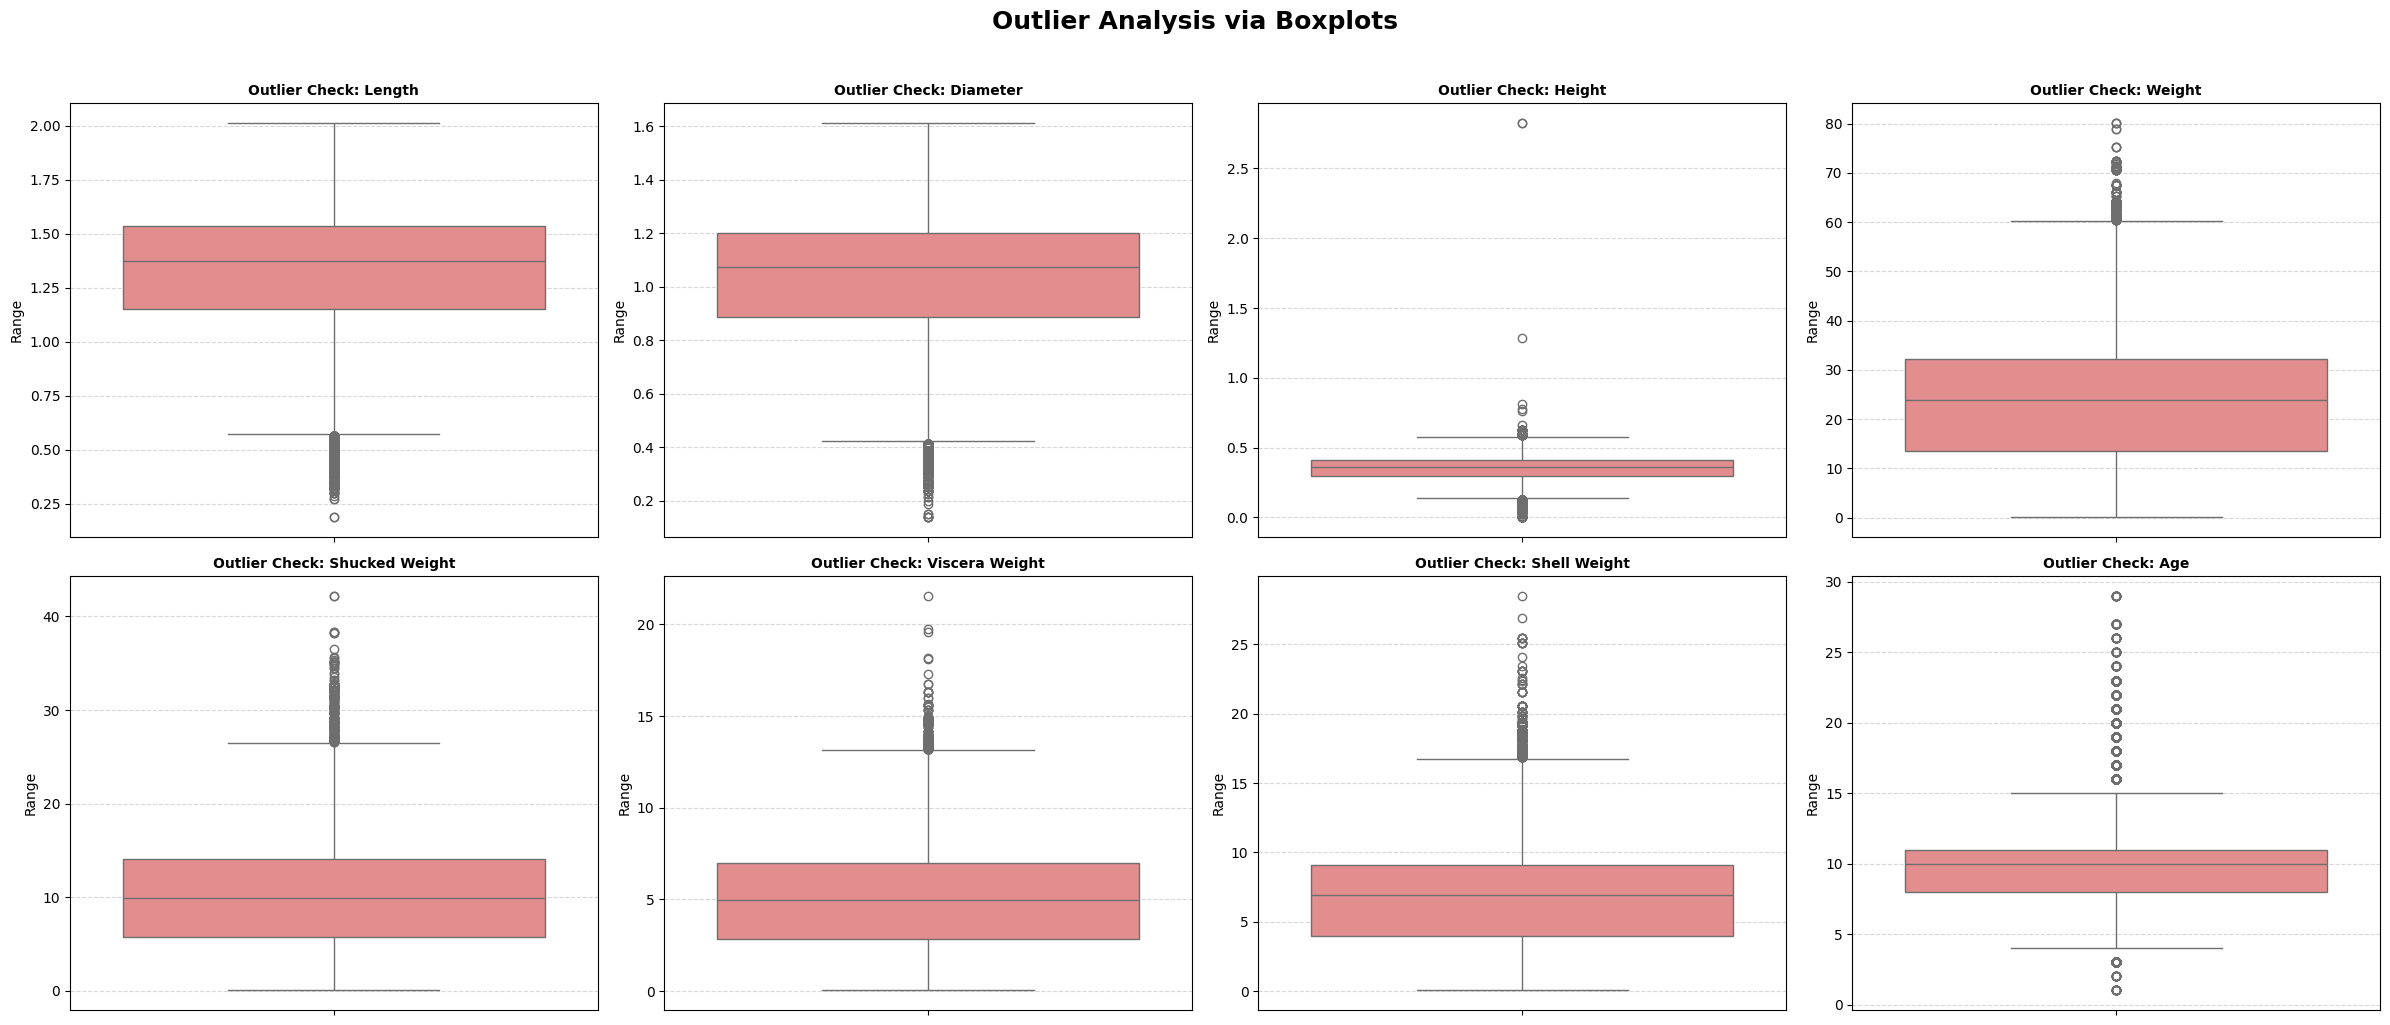

In [13]:
num_features = list(train_df.drop(columns=['id']).select_dtypes(include=['number']).columns)

# Histogram
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

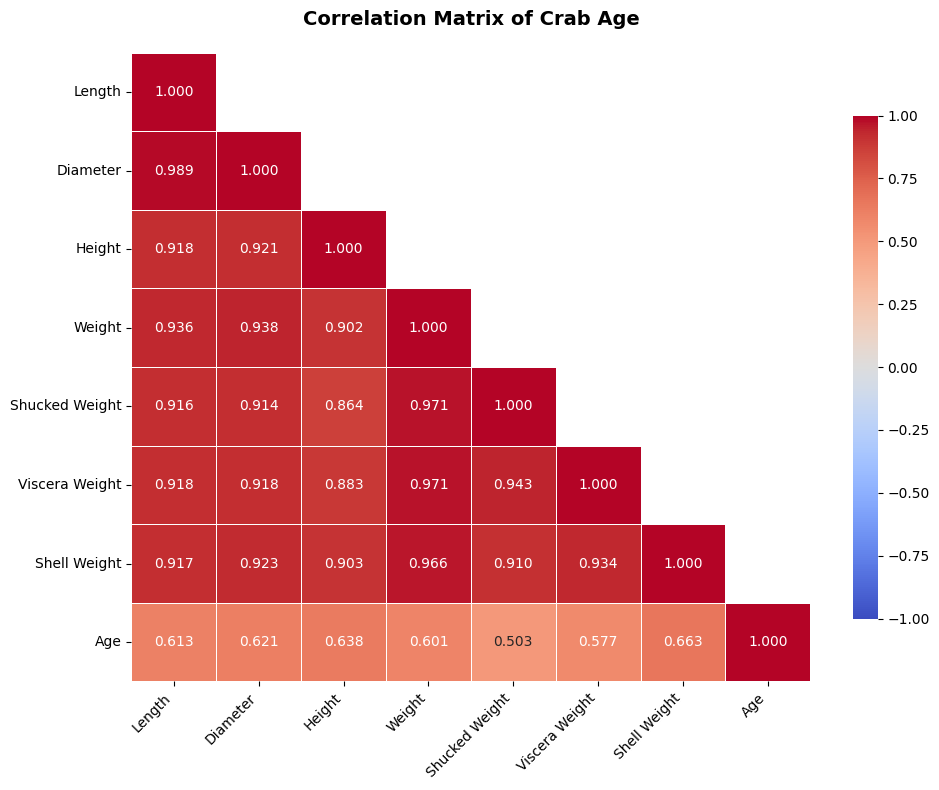

In [14]:
numerical_df = train_df.select_dtypes(include=['number']).drop(columns=['id'], errors='ignore')

corr_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8} 
)

plt.title('Correlation Matrix of Crab Age', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering (FE) & Data Preprocessing

In [15]:
# Create a ratio feature to represent meat density
train_df['Meat_Weight_Ratio'] = train_df['Shucked Weight'] / train_df['Weight']

# Create a volume-like feature using dimensions
train_df['Volume_Proxy'] = train_df['Length'] * train_df['Diameter'] * train_df['Height']

In [16]:
# Dropping highly redundant features to prevent multicollinearity
features_to_drop = ['Diameter', 'Shucked Weight', 'Viscera Weight']
train_df_cleaned = train_df.drop(columns=features_to_drop)

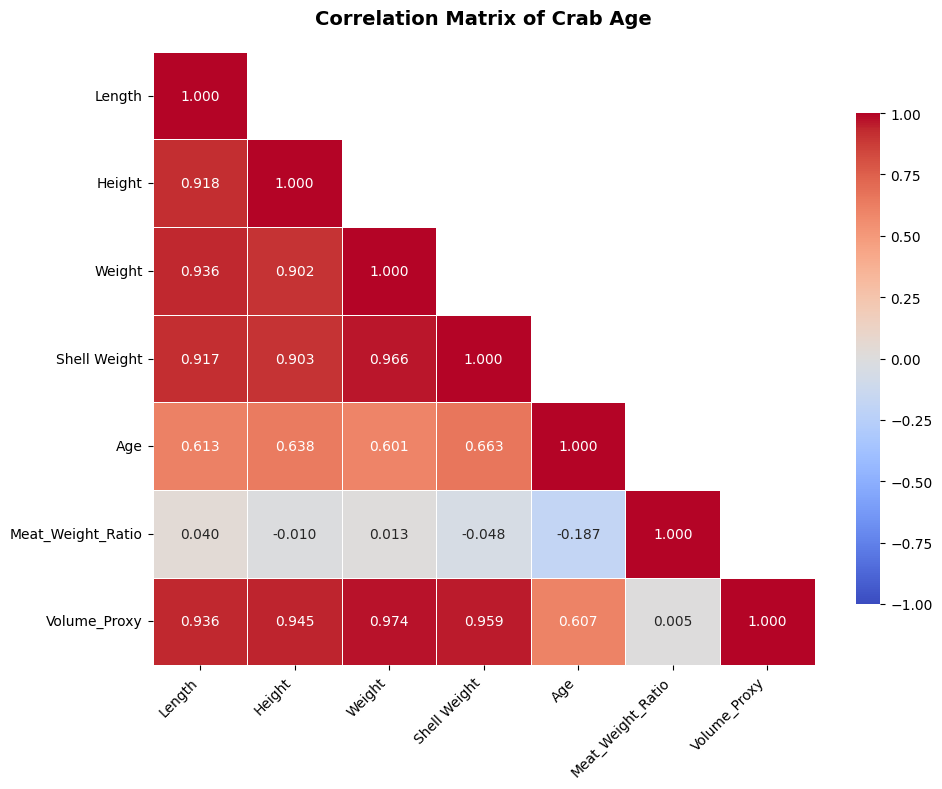

In [17]:
numerical_df = train_df_cleaned.select_dtypes(include=['number']).drop(columns=['id'], errors='ignore')

corr_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix of Crab Age', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
corr_matrix = train_df_cleaned.select_dtypes(include=['number']).drop(columns=['id'], errors='ignore').corr()
age_correlation_table = corr_matrix[['Age']].sort_values(by='Age', ascending=False)

In [19]:
age_correlation_table

,Age
Age,1.000000
Shell Weight,0.663473
Height,0.638067
Length,0.612843
Volume_Proxy,0.607129
Weight,0.601195
Meat_Weight_Ratio,-0.186684


In [20]:
# Create the same ratio feature for meat density in test data
test_df['Meat_Weight_Ratio'] = test_df['Shucked Weight'] / test_df['Weight']

# Create the same volume-like feature in test data
test_df['Volume_Proxy'] = test_df['Length'] * test_df['Diameter'] * test_df['Height']

In [21]:
# Drop the exact same highly redundant features to match train data structure
test_features_to_drop = ['Diameter', 'Shucked Weight', 'Viscera Weight']
test_df_cleaned = test_df.drop(columns=test_features_to_drop)

In [22]:
# Apply One-Hot Encoding to the 'sex' column in training data
train_df_cleaned = pd.get_dummies(train_df_cleaned, columns=['Sex'], drop_first=True)

# Match the categorical encoding with train data
test_df_cleaned = pd.get_dummies(test_df_cleaned, columns=['Sex'], drop_first=True)

In [23]:
train_df_cleaned

,id,Length,Height,Weight,Shell Weight,Age,Meat_Weight_Ratio,Volume_Proxy,Sex_I,Sex_M
0,0,1.5250,0.3750,28.973189,8.348928,9,0.439335,0.671953,True,False
1,1,1.1000,0.2750,10.418441,3.401940,8,0.434014,0.249563,True,False
2,2,1.3875,0.3750,24.777463,6.662133,9,0.457666,0.578848,False,True
3,3,1.7000,0.5000,50.660556,14.996885,11,0.401791,1.200625,False,False
4,4,1.2500,0.3375,23.289114,5.953395,8,0.514303,0.427148,True,False
...,...,...,...,...,...,...,...,...,...,...
74046,74046,1.6625,0.4375,50.660556,12.332033,10,0.408226,0.918271,False,False
74047,74047,1.0750,0.2750,10.446791,3.543687,6,0.413840,0.254977,True,False
74048,74048,1.4875,0.4125,29.483480,8.079607,10,0.417308,0.736312,False,False
74049,74049,1.2125,0.3125,16.768729,4.280774,8,0.535080,0.364697,True,False


## 5. Model Training, Optimization & Deployment Strategy

In [24]:
x = train_df_cleaned.drop(columns=['id', 'Age'], errors='ignore')
y = train_df_cleaned['Age']

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

def algo_test(x, y):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) 
    ada = AdaBoostRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor(n_jobs=-1, random_state=42)                      
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, kn, ada, dt, xgb]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Extra Tree', 'Gradient Boosting', 'KNeighbors', 'AdaBoost', 
        'Decision Tree', 'XGBRegressor'
    ]
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)
    
    for algo, name in zip(algos, algo_names):
        print(f"Now training and evaluating: {name}...")
        
        model_fit = algo.fit(x_train_scaled, y_train)
        predictions = model_fit.predict(x_test_scaled)
        
        r_squared.append(r2_score(y_test, predictions))
        rmse.append(mean_squared_error(y_test, predictions) ** 0.5)
        mae.append(mean_absolute_error(y_test, predictions))
        
        print(f"{name} processing finished successfully.\n")
    
    rtable = result.assign(R_Squared=r_squared, RMSE=rmse, MAE=mae).sort_values('R_Squared', ascending=False)
    return rtable

In [26]:
performance_table = algo_test(x, y)

Now training and evaluating: Linear...
Linear processing finished successfully.

Now training and evaluating: Ridge...
Ridge processing finished successfully.

Now training and evaluating: Lasso...
Lasso processing finished successfully.

Now training and evaluating: ElasticNet...
ElasticNet processing finished successfully.

Now training and evaluating: SGD...
SGD processing finished successfully.

Now training and evaluating: Extra Tree...
Extra Tree processing finished successfully.

Now training and evaluating: Gradient Boosting...
Gradient Boosting processing finished successfully.

Now training and evaluating: KNeighbors...
KNeighbors processing finished successfully.

Now training and evaluating: AdaBoost...
AdaBoost processing finished successfully.

Now training and evaluating: Decision Tree...
Decision Tree processing finished successfully.

Now training and evaluating: XGBRegressor...
XGBRegressor processing finished successfully.



In [27]:
performance_table

,R_Squared,RMSE,MAE
Gradient Boosting,0.583605,2.060029,1.424031
XGBRegressor,0.575169,2.080793,1.429889
Linear,0.530928,2.186452,1.515605
Ridge,0.529606,2.189532,1.518318
SGD,0.501998,2.252869,1.584728
KNeighbors,0.499434,2.258661,1.564013
AdaBoost,0.307574,2.656484,2.130424
Decision Tree,0.130904,2.976147,2.010972
Extra Tree,0.124917,2.986381,2.007810
ElasticNet,0.053137,3.106449,2.277339


In [28]:
x_train_full = train_df_cleaned.drop(columns=['id', 'Age'], errors='ignore')
y_train_full = train_df_cleaned['Age']

In [29]:
x_test_final = test_df_cleaned.drop(columns=['id'], errors='ignore')
x_test_final = x_test_final[x_train_full.columns]

In [30]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_full)
x_test_scaled = scaler.transform(x_test_final)

In [31]:
final_gbr_model = GradientBoostingRegressor(random_state=42)
final_gbr_model.fit(x_train_scaled, y_train_full)

GradientBoostingRegressor(random_state=42)

In [32]:
test_predictions = final_gbr_model.predict(x_test_scaled)

In [33]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Age': test_predictions
})

submission.to_csv('crab_age_submission.csv', index=False)

In [34]:
joblib.dump(final_gbr_model, 'crab_GB.joblib')
joblib.dump(scaler, 'crab_GB_minmax_scaler.joblib')

['crab_GB_minmax_scaler.joblib']

In [35]:

with open('crab_GB.pkl', 'wb') as model_file:
    pickle.dump(final_gbr_model, model_file)

with open('crab_GB_minmax_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
